# 🧪 Evaluador Avanzado de Arquitecturas Cloud (Cloudscape Benchmark)

Este Jupyter Notebook proporciona un marco de evaluación completo y flexible para analizar los grafos de arquitectura generados por los modelos (**Estándar** y **Parsimonioso**) en comparación con el **Ground Truth** manual del dataset Cloudscape.

---

## 📌 Algoritmo y Métricas de Evaluación Utilizadas

### 1. Métricas de Servicios (Nodos)
* **F1 Servicios Únicos (`svc_f1`)**: Evalúa el conjunto de tipos de servicios únicos presentes en la arquitectura (ej. Redshift, S3, EC2). $F1 = \frac{2 \cdot P \cdot R}{P + R}$.
* **F1 Multiset / Nodos Reales (`ms_f1`)**: Considera la multiplicidad de servicios (ej. si hay 2 Lambdas en el Ground Truth y el modelo genera 1, se penaliza mediante la intersección de multiconjuntos `Counter`).

### 2. Métricas Estándar de Conexiones (Aristas)
* **F1 Aristas Dirigidas Multiset (`std_edge_f1`)**: Compara pares dirigidos `(Servicio_Origen -> Servicio_Destino)`. Si el Ground Truth tiene `A -> B` y el modelo genera `B -> A`, o si falta la ruta de retorno `B -> A`, la evaluación estándar la penaliza como omisión/error.
* **Precisión de Tipo (`edge_type_accuracy`)**: Mide el porcentaje de aristas que, además de coincidir en origen y destino, coinciden en el tipo de flujo (`data` vs `control`).

### 3. 💡 Nueva Métrica Permisiva: Conectividad Base No Dirigida (`base_edge_f1`)
* **Motivación**: En diagramas de arquitectura, los ciclos de petición-respuesta (ida y vuelta) suelen anotarse como dos flechas separadas. Si el modelo predice la relación estructural básica entre el servicio A y B (ej. `A -> B`), la evaluación estándar penaliza la falta del camino de regreso `B -> A`.
* **Algoritmo Permisivo**: Convierte las aristas dirigidas en pares no dirigidos únicos: `(min(Servicio_A, Servicio_B), max(Servicio_A, Servicio_B))`. Evalúa si la **conexión base** existe estructuralmente entre los dos componentes sin penalizar la dirección exacta de la flecha ni las respuestas de retorno duplicadas.

In [1]:
import os
import csv
import json
import pandas as pd
import numpy as np
import networkx as nx
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# Cargar catálogo de servicios
PROJECT_ROOT = Path("/home/stemjara/Projects/AWS-Architecture")
SERVICES_CSV = PROJECT_ROOT / "data" / "cloudscape_gt" / "services.csv"

def load_services_catalog(csv_path=SERVICES_CSV):
    catalog = {}
    if not csv_path.exists():
        return catalog
    with open(csv_path, mode="r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            name = row.get("name", "").strip()
            if name:
                catalog[name] = {
                    "capability": row.get("capability", "").strip(),
                    "is_aws": row.get("is_aws", "").strip() == "True",
                    "schema": row.get("schema", "").strip(),
                }
    return catalog

CATALOG = load_services_catalog()
print(f"✅ Catálogo de servicios cargado: {len(CATALOG)} servicios reconocidos.")

✅ Catálogo de servicios cargado: 169 servicios reconocidos.


In [2]:
# ==========================================
# 🛠️ FUNCIONES CORE DE EVALUACIÓN (ESTÁNDAR Y PERMISIVA)
# ==========================================
def extract_service_set(G):
    return {G.nodes[n].get("service", "") for n in G.nodes() if G.nodes[n].get("service")}

def extract_service_multiset(G):
    return [G.nodes[n].get("service", "") for n in G.nodes() if G.nodes[n].get("service")]

def extract_directed_edges(G):
    pairs = []
    for s, t, attrs in G.edges(data=True):
        ss = G.nodes[s].get("service", "?")
        ts = G.nodes[t].get("service", "?")
        pairs.append((ss, ts))
    return pairs

def extract_base_undirected_pairs(G):
    pairs = set()
    for s, t, _ in G.edges(data=True):
        ss = G.nodes[s].get("service", "?")
        ts = G.nodes[t].get("service", "?")
        if ss and ts and ss != "?" and ts != "?":
            pairs.add(tuple(sorted([ss, ts])))
    return pairs

def compute_precision_recall_f1(intersection_count, gen_count, gt_count):
    p = intersection_count / gen_count if gen_count > 0 else 0.0
    r = intersection_count / gt_count if gt_count > 0 else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    return p, r, f1

def evaluate_single_pair(gen_graph, gt_graph, video_id):
    # 1. Servicios Únicos
    gen_svc_set = extract_service_set(gen_graph)
    gt_svc_set = extract_service_set(gt_graph)
    svc_p, svc_r, svc_f1 = compute_precision_recall_f1(len(gen_svc_set & gt_svc_set), len(gen_svc_set), len(gt_svc_set))
    
    # 2. Servicios Multiset
    gen_svc_list = extract_service_multiset(gen_graph)
    gt_svc_list = extract_service_multiset(gt_graph)
    c_gen_svc = Counter(gen_svc_list)
    c_gt_svc = Counter(gt_svc_list)
    ms_inter = sum((c_gen_svc & c_gt_svc).values())
    ms_p, ms_r, ms_f1 = compute_precision_recall_f1(ms_inter, len(gen_svc_list), len(gt_svc_list))
    
    # 3. Aristas Dirigidas (Estándar)
    gen_dir_edges = extract_directed_edges(gen_graph)
    gt_dir_edges = extract_directed_edges(gt_graph)
    c_gen_edge = Counter(gen_dir_edges)
    c_gt_edge = Counter(gt_dir_edges)
    dir_inter = sum((c_gen_edge & c_gt_edge).values())
    edge_p, edge_r, edge_f1 = compute_precision_recall_f1(dir_inter, len(gen_dir_edges), len(gt_dir_edges))
    
    # 4. Aristas Base No Dirigidas (Permisiva)
    gen_base_pairs = extract_base_undirected_pairs(gen_graph)
    gt_base_pairs = extract_base_undirected_pairs(gt_graph)
    base_inter = len(gen_base_pairs & gt_base_pairs)
    base_p, base_r, base_f1 = compute_precision_recall_f1(base_inter, len(gen_base_pairs), len(gt_base_pairs))
    
    usable = gt_graph.graph.get("graph_usable", True)
    if usable is False or str(usable).lower() == "false":
        graph_usable = False
    else:
        graph_usable = True
        
    return {
        "video_id": video_id,
        "gt_name": gt_graph.graph.get("name", f"Video {video_id}"),
        "graph_usable": graph_usable,
        "gen_nodes": gen_graph.number_of_nodes(),
        "gt_nodes": gt_graph.number_of_nodes(),
        "svc_precision": svc_p,
        "svc_recall": svc_r,
        "svc_f1": svc_f1,
        "ms_precision": ms_p,
        "ms_recall": ms_r,
        "ms_f1": ms_f1,
        "gen_edges": gen_graph.number_of_edges(),
        "gt_edges": gt_graph.number_of_edges(),
        "std_edge_precision": edge_p,
        "std_edge_recall": edge_r,
        "std_edge_f1": edge_f1,
        "base_edge_count_gen": len(gen_base_pairs),
        "base_edge_count_gt": len(gt_base_pairs),
        "base_edge_precision": base_p,
        "base_edge_recall": base_r,
        "base_edge_f1": base_f1,
        "services_correct": sorted(list(gen_svc_set & gt_svc_set)),
        "services_missing": sorted(list(gt_svc_set - gen_svc_set)),
        "services_hallucinated": sorted(list(gen_svc_set - gt_svc_set)),
        "base_edges_correct": sorted([f"{a}<->{b}" for a, b in (gen_base_pairs & gt_base_pairs)]),
        "base_edges_missing": sorted([f"{a}<->{b}" for a, b in (gt_base_pairs - gen_base_pairs)]),
        "base_edges_hallucinated": sorted([f"{a}<->{b}" for a, b in (gen_base_pairs - gt_base_pairs)]),
    }

print("✅ Funciones de evaluación estándar y permisiva cargadas correctamente.")

✅ Funciones de evaluación estándar y permisiva cargadas correctamente.


## 🎥 1. Evaluación de Video Individual
Utiliza esta celda para seleccionar cualquier `VIDEO_ID` y evaluar de forma independiente el rendimiento de su grafo generado respecto a su Ground Truth.

In [3]:
# ==========================================
# 🎯 ANÁLISIS DE UN VIDEO INDIVIDUAL
# ==========================================
VIDEO_ID = "ww5fiygF6eg"  # Modifica este ID para probar otro video
CARPETA_MODELO = "data/graphs_parsimonious"  # Opciones: "data/graphs" o "data/graphs_parsimonious"

path_gt = PROJECT_ROOT / "data" / "cloudscape_gt" / f"{VIDEO_ID}.graphml"
path_gen = PROJECT_ROOT / CARPETA_MODELO / f"{VIDEO_ID}.graphml"

if not path_gt.exists():
    print(f"❌ No se encontró Ground Truth en: {path_gt}")
elif not path_gen.exists():
    print(f"❌ No se encontró grafo generado en: {path_gen}")
else:
    g_gt = nx.read_graphml(str(path_gt))
    g_gen = nx.read_graphml(str(path_gen))
    
    res = evaluate_single_pair(g_gen, g_gt, VIDEO_ID)
    
    print("=" * 65)
    print(f"📌 RESUMEN DE EVALUACIÓN INDIVIDUAL: {VIDEO_ID}")
    print(f"   Título: {res["gt_name"]}")
    print(f"   Modelo evaluado: {CARPETA_MODELO}")
    print("=" * 65)
    
    print("\n📊 MÉTRICAS DE SERVICIOS (NODOS):")
    print(f"  • Nodos Generados: {res["gen_nodes"]} | Nodos GT: {res["gt_nodes"]}")
    print(f"  • F1 Servicios Únicos: {res["svc_f1"]:.1%} (Precisión: {res["svc_precision"]:.1%}, Recall: {res["svc_recall"]:.1%})")
    print(f"  • F1 Nodos Multiset:  {res["ms_f1"]:.1%}")
    print(f"  • Servicios Correctos:     {res["services_correct"]}")
    print(f"  • Servicios Faltantes:     {res["services_missing"]}")
    print(f"  • Servicios Alucinados:    {res["services_hallucinated"]}")
    
    print("\n🔗 MÉTRICAS DE CONEXIONES (ARISTAS):")
    print(f"  • [ESTÁNDAR]   F1 Aristas Dirigidas: {res["std_edge_f1"]:.1%} (Precisión: {res["std_edge_precision"]:.1%}, Recall: {res["std_edge_recall"]:.1%})")
    print(f"  • [PERMISIVO]  F1 Conectividad Base: {res["base_edge_f1"]:.1%} (Precisión: {res["base_edge_precision"]:.1%}, Recall: {res["base_edge_recall"]:.1%})")
    print(f"  • Conexiones Base Correctas:   {res["base_edges_correct"]}")
    print(f"  • Conexiones Base Faltantes:   {res["base_edges_missing"]}")
    print(f"  • Conexiones Base Alucinadas:  {res["base_edges_hallucinated"]}")
    print("=" * 65)

📌 RESUMEN DE EVALUACIÓN INDIVIDUAL: ww5fiygF6eg
   Título: Marathon Oil: Automating Drone Image Processing to Monitor Equipment Health
   Modelo evaluado: data/graphs_parsimonious

📊 MÉTRICAS DE SERVICIOS (NODOS):
  • Nodos Generados: 8 | Nodos GT: 10
  • F1 Servicios Únicos: 66.7% (Precisión: 62.5%, Recall: 71.4%)
  • F1 Nodos Multiset:  55.6%
  • Servicios Correctos:     ['Lambda', 'S3', 'StepFunctions', 'StorageGateway', 'ThirdParty']
  • Servicios Faltantes:     ['CloudWatch', 'UserCompanyDrone']
  • Servicios Alucinados:    ['EventBridge', 'OnPremDC', 'UserCompanyAgent']

🔗 MÉTRICAS DE CONEXIONES (ARISTAS):
  • [ESTÁNDAR]   F1 Aristas Dirigidas: 21.4% (Precisión: 37.5%, Recall: 15.0%)
  • [PERMISIVO]  F1 Conectividad Base: 40.0% (Precisión: 37.5%, Recall: 42.9%)
  • Conexiones Base Correctas:   ['Lambda<->StepFunctions', 'Lambda<->ThirdParty', 'S3<->StorageGateway']
  • Conexiones Base Faltantes:   ['CloudWatch<->StepFunctions', 'Lambda<->S3', 'StorageGateway<->ThirdParty', 'Third

## 📂 2. Evaluación Masiva de la Carpeta de un Modelo
Evalúa de golpe **todos los videos disponibles** en una carpeta específica del modelo (`data/graphs_parsimonious/` o `data/graphs/`) contra el conjunto de Ground Truths.

✅ Evaluación Masiva Completada:
   • Carpeta: data/graphs_parsimonious
   • Total Archivos Encontrados: 118
   • Coincidencias con Ground Truth: 94
   • Grafos Válidos Evaluados (Core Benchmark): 83

📊 TABLA RESUMEN GLOBAL (ESTÁNDAR VS PERMISIVO):
                                              Métrica de Evaluación Promedio (Mean) Mediana (Median)
                                       F1 Servicios Únicos (svc_f1)           84.9%            85.7%
                                          F1 Nodos Multiset (ms_f1)           83.4%            85.7%
             F1 Aristas Estándar [Dirigidas Multiset] (std_edge_f1)           56.6%            55.2%
F1 Aristas Permisivo [Conectividad Base No Dirigida] (base_edge_f1)           68.8%            70.0%


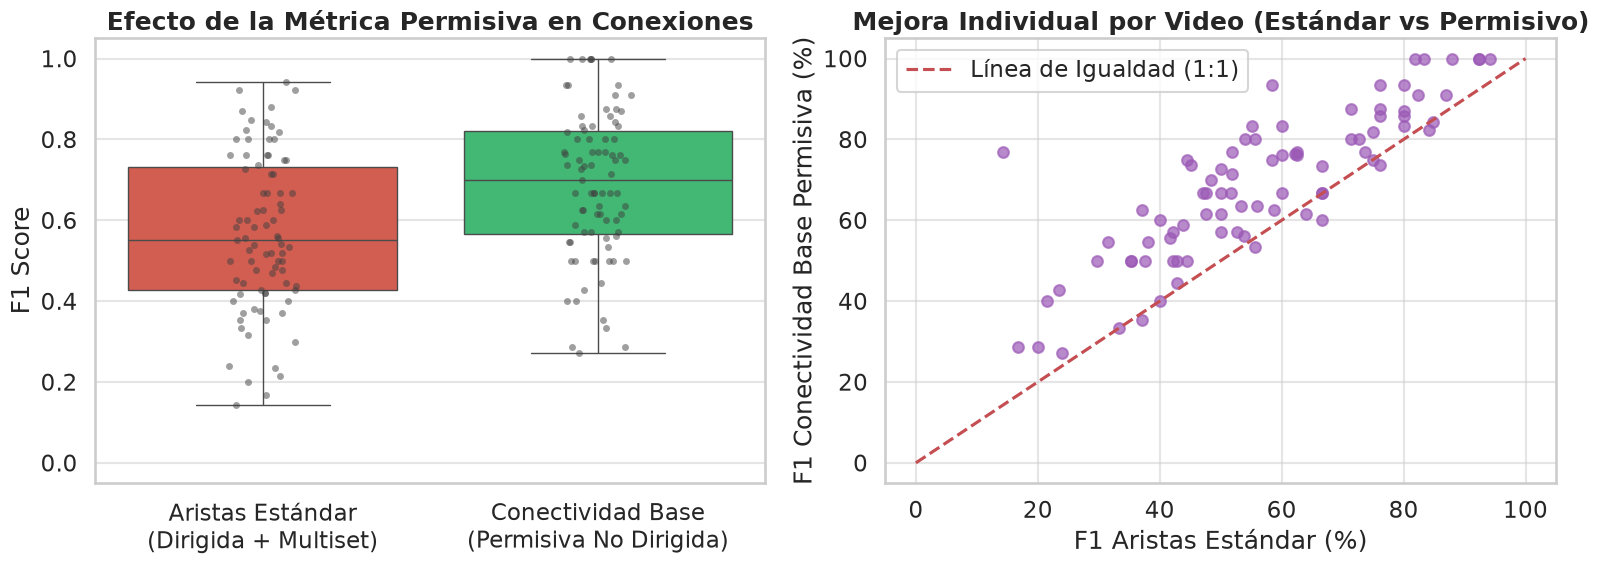


📋 MUESTRA DE RESULTADOS POR VIDEO (Primeros 15):
   video_id  gt_nodes  gen_nodes svc_f1 std_edge_f1 base_edge_f1
-3lnf5lzsH0        13          9  73.7%       24.0%        27.3%
-S-R7MWRpaI         8          9  83.3%       42.1%        50.0%
-ahWdCysMYw         8          7  93.3%       14.3%        76.9%
-kA0ahrhX3I         9         11  85.7%       55.6%        80.0%
-wLEkq21cvA         9          9 100.0%       80.0%        85.7%
07lfvavMdfU        10         10 100.0%       80.0%        87.0%
0F7KDLz-kIQ        13         14  87.0%       62.2%        76.5%
0JxJpNjI9Y0         9         10  80.0%       51.9%        71.4%
0gNMEyei-co         9          9  94.1%       75.0%        81.8%
0wnNlOg42dc         8          9  94.1%       76.2%        93.3%
1aYoIZvabbk         6          7  92.3%       66.7%        66.7%
1xLjtJnfZes         8          8  80.0%       66.7%        66.7%
2L0m28ZLmtE        13         14  96.0%       87.0%        90.9%
2XVgpMwY5iE         7          8  71.4% 

In [4]:
# ==========================================
# 🚀 EVALUACIÓN EN LOTE DE TODA LA CARPETA
# ==========================================
CARPETA_OBJETIVO = "data/graphs_parsimonious"  # Opciones: "data/graphs_parsimonious" o "data/graphs"

dir_gen = PROJECT_ROOT / CARPETA_OBJETIVO
dir_gt = PROJECT_ROOT / "data" / "cloudscape_gt"

files_gen = {f.stem: f for f in dir_gen.glob("*.graphml")}
files_gt = {f.stem: f for f in dir_gt.glob("*.graphml")}

matching_vids = sorted(set(files_gen.keys()) & set(files_gt.keys()))

results_list = []
for vid in matching_vids:
    g_gt = nx.read_graphml(str(files_gt[vid]))
    g_gen = nx.read_graphml(str(files_gen[vid]))
    r = evaluate_single_pair(g_gen, g_gt, vid)
    results_list.append(r)

df_results = pd.DataFrame(results_list)
df_valid = df_results[df_results["graph_usable"] == True].copy()

print(f"✅ Evaluación Masiva Completada:")
print(f"   • Carpeta: {CARPETA_OBJETIVO}")
print(f"   • Total Archivos Encontrados: {len(files_gen)}")
print(f"   • Coincidencias con Ground Truth: {len(matching_vids)}")
print(f"   • Grafos Válidos Evaluados (Core Benchmark): {len(df_valid)}")

# Tabla Resumen de Promedios
resumen_promedios = pd.DataFrame({
    "Métrica de Evaluación": [
        "F1 Servicios Únicos (svc_f1)",
        "F1 Nodos Multiset (ms_f1)",
        "F1 Aristas Estándar [Dirigidas Multiset] (std_edge_f1)",
        "F1 Aristas Permisivo [Conectividad Base No Dirigida] (base_edge_f1)"
    ],
    "Promedio (Mean)": [
        df_valid["svc_f1"].mean(),
        df_valid["ms_f1"].mean(),
        df_valid["std_edge_f1"].mean(),
        df_valid["base_edge_f1"].mean()
    ],
    "Mediana (Median)": [
        df_valid["svc_f1"].median(),
        df_valid["ms_f1"].median(),
        df_valid["std_edge_f1"].median(),
        df_valid["base_edge_f1"].median()
    ]
})

resumen_promedios["Promedio (Mean)"] = resumen_promedios["Promedio (Mean)"].apply(lambda x: f"{x:.1%}")
resumen_promedios["Mediana (Median)"] = resumen_promedios["Mediana (Median)"].apply(lambda x: f"{x:.1%}")

print("\n📊 TABLA RESUMEN GLOBAL (ESTÁNDAR VS PERMISIVO):")
print(resumen_promedios.to_string(index=False))

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Comparación Boxplot Estándar vs Permisivo
df_plot_edges = df_valid.melt(
    value_vars=["std_edge_f1", "base_edge_f1"], 
    var_name="Tipo de Métrica", 
    value_name="F1 Score"
)
df_plot_edges["Tipo de Métrica"] = df_plot_edges["Tipo de Métrica"].map({
    "std_edge_f1": "Aristas Estándar\n(Dirigida + Multiset)",
    "base_edge_f1": "Conectividad Base\n(Permisiva No Dirigida)"
})

sns.boxplot(x="Tipo de Métrica", y="F1 Score", hue="Tipo de Métrica", data=df_plot_edges, ax=axes[0], palette=["#e74c3c", "#2ecc71"], legend=False)
sns.stripplot(x="Tipo de Métrica", y="F1 Score", data=df_plot_edges, ax=axes[0], color=".25", alpha=0.5, size=5)
axes[0].set_title("Efecto de la Métrica Permisiva en Conexiones", fontweight="bold")
axes[0].set_ylim(-0.05, 1.05)
axes[0].set_ylabel("F1 Score")
axes[0].set_xlabel("")

# 2. Scatter plot Estándar vs Permisivo por Video
axes[1].scatter(df_valid["std_edge_f1"] * 100, df_valid["base_edge_f1"] * 100, color="#9b59b6", alpha=0.7, s=60)
axes[1].plot([0, 100], [0, 100], "r--", label="Línea de Igualdad (1:1)")
axes[1].set_title("Mejora Individual por Video (Estándar vs Permisivo)", fontweight="bold")
axes[1].set_xlabel("F1 Aristas Estándar (%)")
axes[1].set_ylabel("F1 Conectividad Base Permisiva (%)")
axes[1].set_xlim(-5, 105)
axes[1].set_ylim(-5, 105)
axes[1].legend()

plt.tight_layout()
plt.show()

# Mostrar DataFrame detallado de videos
print("\n📋 MUESTRA DE RESULTADOS POR VIDEO (Primeros 15):")
cols_view = ["video_id", "gt_nodes", "gen_nodes", "svc_f1", "std_edge_f1", "base_edge_f1"]
df_view = df_valid[cols_view].copy()
for col in ["svc_f1", "std_edge_f1", "base_edge_f1"]:
    df_view[col] = df_view[col].apply(lambda x: f"{x:.1%}")
print(df_view.head(15).to_string(index=False))